**1. Exploración y análisis del dataset**


• Revisa la estructura de las carpetas, cantidad de imágenes disponibles 
por clase y formato de datos. 

• Realiza un breve análisis exploratorio: ejemplos de imágenes, 
distribución de clases y posibles retos del dataset (desbalance, 
resolución, etc.). 

In [ ]:
import kagglehub
from PIL import Image
import os

# Descargar dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path) 

Resuming download from 2311061504 bytes (152303931 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/chest-xray-pneumonia?dataset_version_number=2 (2311061504/2463365435) bytes left.


100%|██████████| 2.29G/2.29G [00:44<00:00, 3.43MB/s]

Extracting files...


Path to dataset files: C:\Users\león\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [ ]:

# Ruta dataset
path = r"C:\Users\león\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray"

# Contar imágenes por clase
print("\nCANTIDAD DE IMÁGENES")
for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()}:")
    for clase in ['NORMAL', 'PNEUMONIA']:
        clase_path = os.path.join(path, split, clase)
        if os.path.exists(clase_path):
            num_images = len(os.listdir(clase_path))
            print(f"  {clase}: {num_images} imágenes")


CANTIDAD DE IMÁGENES

TRAIN:
  NORMAL: 1342 imágenes
  PNEUMONIA: 3876 imágenes

TEST:
  NORMAL: 234 imágenes
  PNEUMONIA: 390 imágenes

VAL:
  NORMAL: 9 imágenes
  PNEUMONIA: 9 imágenes


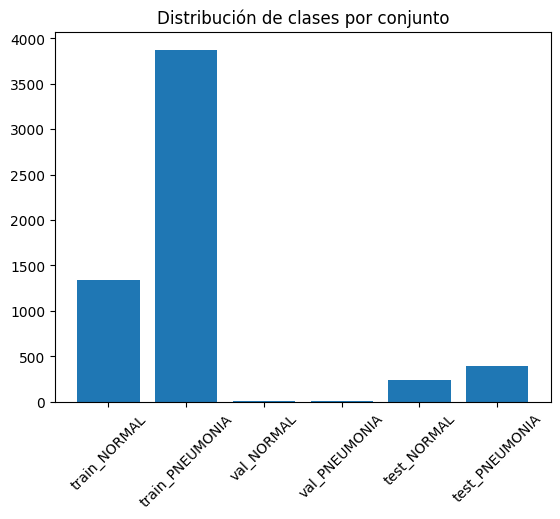

In [46]:
import matplotlib.pyplot as plt

datos = {'train_NORMAL': 1342, 'train_PNEUMONIA': 3876,
         'val_NORMAL': 9, 'val_PNEUMONIA': 9,
         'test_NORMAL': 234, 'test_PNEUMONIA': 390}

plt.bar(datos.keys(), datos.values())
plt.xticks(rotation=45)
plt.title('Distribución de clases por conjunto')
plt.show()


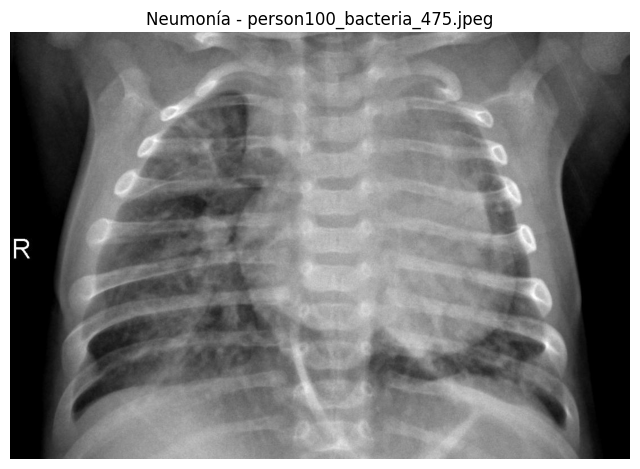

Imagen mostrada: person100_bacteria_475.jpeg


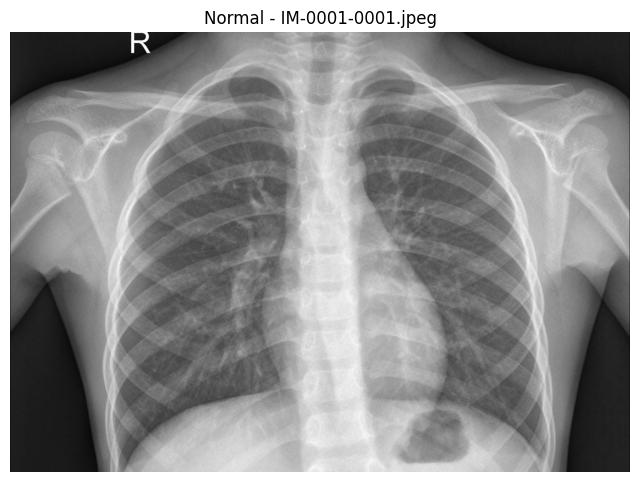

Imagen mostrada: IM-0001-0001.jpeg


In [47]:
from tensorflow.keras.preprocessing import image

# Cargar una imagen de ejemplo (PNEUMONIA)
pneumonia_path = os.path.join(path, 'test', 'PNEUMONIA')
imagen_ejemplo_pneumonia = os.listdir(pneumonia_path)[0]  # Primera imagen en chestxray/test/PNEUMONIA
img_completa_pneumonia = os.path.join(pneumonia_path, imagen_ejemplo_pneumonia)

# Cargar una imagen de ejemplo (NORMAL)
normal_path = os.path.join(path, 'test', 'NORMAL')
imagen_ejemplo_normal = os.listdir(normal_path)[0]  # Primera imagen en chestxray/test/PNEUMONIA
img_completa_normal = os.path.join(normal_path, imagen_ejemplo_normal)

# Cargar y mostrar imagen (PNEUMONIA)
i = image.load_img(img_completa_pneumonia)

plt.figure(figsize=(8, 6))
plt.imshow(i, cmap='gray')
plt.title(f'Neumonía - {imagen_ejemplo_pneumonia}')
plt.axis('off')
plt.show()

print(f"Imagen mostrada: {imagen_ejemplo_pneumonia}")

# Cargar y mostrar imagen (NORMAL)
i = image.load_img(img_completa_normal)

plt.figure(figsize=(8, 6))
plt.imshow(i, cmap='gray')
plt.title(f'Normal - {imagen_ejemplo_normal}')
plt.axis('off')
plt.show()

print(f"Imagen mostrada: {imagen_ejemplo_normal}")

In [48]:
# Función para analizar una imagen
def analizar_imagen(ruta_img):
    img = image.load_img(ruta_img)

    print("FORMATO DE DATOS\n")
    print(f"Nombre del archivo: {os.path.basename(ruta_img)}")
    print(f"Ruta completa: {ruta_img}")
    print(f"Formato de archivo: {img.format}")      # No muestra formato (None) porque ya paso por image.load_img()
    print(f"Dimensiones (ancho x alto): {img.size}")  # (ancho, alto)
    print(f"Modo (canales): {img.mode}")            # L = escala de grises, RGB = color
    print(f"Tamaño del archivo: {os.path.getsize(ruta_img) / 1024:.2f} KB")
    print("-" * 50)

# Analizar imágenes de ejemplo
analizar_imagen(img_completa_pneumonia)
analizar_imagen(img_completa_normal)





FORMATO DE DATOS

Nombre del archivo: person100_bacteria_475.jpeg
Ruta completa: C:\Users\león\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg
Formato de archivo: None
Dimensiones (ancho x alto): (1106, 762)
Modo (canales): RGB
Tamaño del archivo: 75.58 KB
--------------------------------------------------
FORMATO DE DATOS

Nombre del archivo: IM-0001-0001.jpeg
Ruta completa: C:\Users\león\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray\test\NORMAL\IM-0001-0001.jpeg
Formato de archivo: None
Dimensiones (ancho x alto): (1857, 1317)
Modo (canales): RGB
Tamaño del archivo: 246.76 KB
--------------------------------------------------


In [49]:
#Ver el formato de la imagen (person100_bacteria_475.jpeg)

imagen_neumonia = Image.open(r'C:\Users\león\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg')
print(f"Formato de archivo: {img.format}")


Formato de archivo: JPEG


**Análisis del dataset**

**Contenido del dataset:**

El dataset está organizado en tres carpetas principales: Train, Validation y Test.
Cada una contiene dos subcarpetas correspondientes a las clases Neumonía y Normal.
En total, el conjunto incluye 5.860 imágenes de rayos X en formato JPEG, distribuidas en las dos categorías mencionadas.

**Reto principal del dataset:**

Al analizar la distribución de las imágenes, se observa un marcado desbalance entre clases, donde la cantidad de radiografías de Neumonía supera ampliamente a las de Normal, especialmente en el conjunto de entrenamiento.
Este desbalance puede generar un sesgo en el aprendizaje del modelo, llevándolo a favorecer la predicción de la clase mayoritaria y reduciendo su capacidad para identificar correctamente los casos normales.

Para mitigar este problema, será necesario aplicar estrategias como aumentación de datos (data augmentation) en la clase minoritaria, ponderación de clases durante el entrenamiento o recolección de datos adicionales, de modo que el modelo pueda aprender de manera equilibrada y mejorar su capacidad de generalización.